# 0

In [2]:
import fastf1 
import fastf1.plotting

import pandas as pd
import matplotlib.pyplot as plt


In [3]:
session = fastf1.get_session(2026, 3, 'Q')
session.load()

session.event

req         WARNING 	DEFAULT CACHE ENABLED! (50.81 MB) C:\Users\arkan\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api        

RoundNumber                                                  3
Country                                                  Japan
Location                                                Suzuka
OfficialEventName    FORMULA 1 ARAMCO JAPANESE GRAND PRIX 2026
EventDate                                  2026-03-29 00:00:00
EventName                                  Japanese Grand Prix
EventFormat                                       conventional
Session1                                            Practice 1
Session1Date                         2026-03-27 11:30:00+09:00
Session1DateUtc                            2026-03-27 02:30:00
Session2                                            Practice 2
Session2Date                         2026-03-27 15:00:00+09:00
Session2DateUtc                            2026-03-27 06:00:00
Session3                                            Practice 3
Session3Date                         2026-03-28 11:30:00+09:00
Session3DateUtc                            2026-03-28 0

In [3]:
session.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,1.0,,NaN,0 days 00:01:30.035000,0 days 00:01:29.048000,0 days 00:01:28.778000,NaT,,NaN,NaN
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,2.0,,NaN,0 days 00:01:29.967000,0 days 00:01:29.686000,0 days 00:01:29.076000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,3.0,,NaN,0 days 00:01:30.200000,0 days 00:01:29.451000,0 days 00:01:29.132000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,4.0,,NaN,0 days 00:01:29.915000,0 days 00:01:29.303000,0 days 00:01:29.405000,NaT,,NaN,NaN
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,5.0,,NaN,0 days 00:01:30.401000,0 days 00:01:29.795000,0 days 00:01:29.409000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,6.0,,NaN,0 days 00:01:30.309000,0 days 00:01:29.589000,0 days 00:01:29.567000,NaT,,NaN,NaN
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,7.0,,NaN,0 days 00:01:30.584000,0 days 00:01:29.874000,0 days 00:01:29.691000,NaT,,NaN,NaN
6,6,I HADJAR,HAD,hadjar,Red Bull Racing,4781D7,red_bull,Isack,Hadjar,Isack Hadjar,...,8.0,,NaN,0 days 00:01:30.662000,0 days 00:01:30.104000,0 days 00:01:29.978000,NaT,,NaN,NaN
5,5,G BORTOLETO,BOR,bortoleto,Audi,F50537,audi,Gabriel,Bortoleto,Gabriel Bortoleto,...,9.0,,NaN,0 days 00:01:30.359000,0 days 00:01:29.990000,0 days 00:01:30.274000,NaT,,NaN,NaN
41,41,A LINDBLAD,LIN,arvid_lindblad,Racing Bulls,6C98FF,rb,Arvid,Lindblad,Arvid Lindblad,...,10.0,,NaN,0 days 00:01:30.781000,0 days 00:01:30.109000,0 days 00:01:30.319000,NaT,,NaN,NaN


# 1

In [4]:
dvr_1 = 'VER'
dvr_2 = 'PIA'

dvr_1_lap = session.laps.pick_drivers(dvr_1).pick_fastest()
dvr_2_lap = session.laps.pick_drivers(dvr_2).pick_fastest()

dvr_1_tel = dvr_1_lap.get_car_data().add_distance()
dvr_2_tel = dvr_2_lap.get_car_data().add_distance()

dvr_1_team_col = fastf1.plotting.get_team_color(dvr_1_lap['Team'], session=session)
dvr_2_team_col = fastf1.plotting.get_team_color(dvr_2_lap['Team'], session=session)

req            INFO 	Using cached data for driver_info


In [6]:
# replace value greater than 100 with 100
dvr_1_tel.loc[dvr_1_tel['Throttle'] > 100, 'Throttle'] = 100

C:\Users\arkan\AppData\Local\Temp\ipykernel_18736\2334646774.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


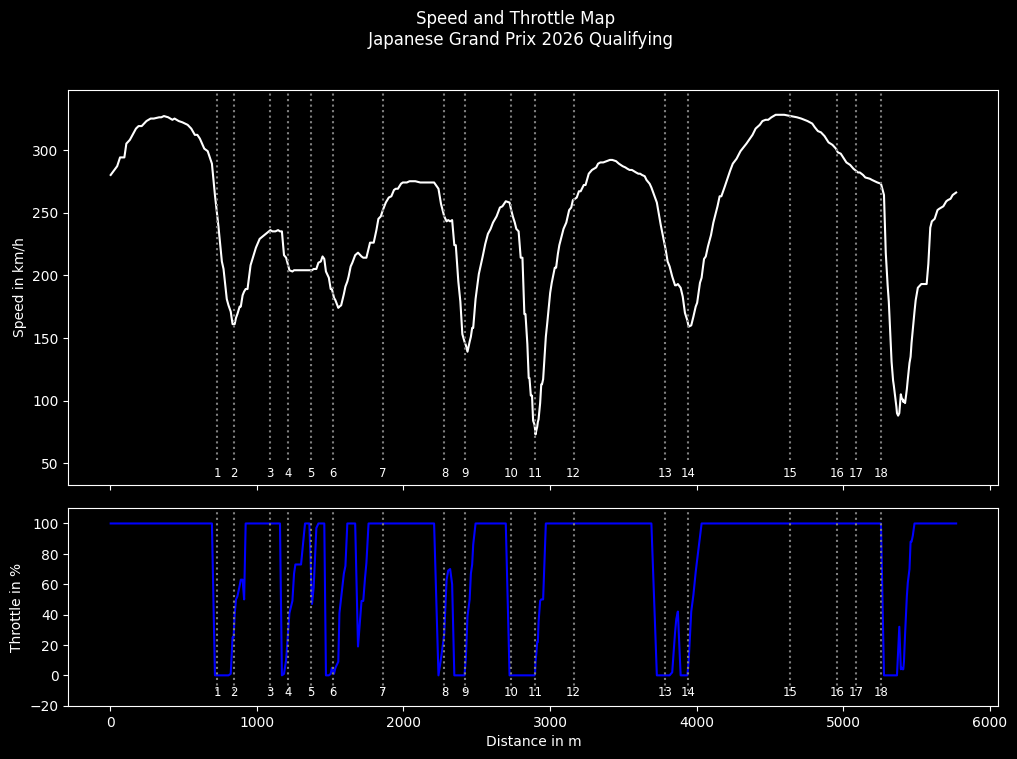

In [7]:
# Prepare circuit info for a combined speed and throttle view
circuit_info = session.get_circuit_info()

# Create figure with two subplots: speed on top, throttle below
fig, (ax_speed, ax_throttle) = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08}
)
fig.patch.set_facecolor('black')

# Style axes with dark background and white ticks
for ax in (ax_speed, ax_throttle):
    ax.set_facecolor('black')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    for spine in ax.spines.values():
        spine.set_color('white')

# Plot speed vs distance
ax_speed.plot(
    dvr_1_tel['Distance'],
    dvr_1_tel['Speed'],
    color='white',
    label=dvr_1
)

# Plot throttle vs distance
ax_throttle.plot(
    dvr_1_tel['Distance'],
    dvr_1_tel['Throttle'],
    color='blue',
    label=dvr_1
)

# Set axis labels
ax_speed.set_ylabel('Speed in km/h', color='white')
ax_throttle.set_ylabel('Throttle in %', color='white')
ax_throttle.set_xlabel('Distance in m', color='white')

# Set plot title with event information
plt.suptitle(f"Speed and Throttle Map \n "
             f"{session.event['EventName']} {session.event.year} Qualifying", color='white')

# Determine min/max values for speed and throttle
speed_min = dvr_1_tel['Speed'].min()
speed_max = dvr_1_tel['Speed'].max()
throttle_min = dvr_1_tel['Throttle'].min()
throttle_max = dvr_1_tel['Throttle'].max()

# Add vertical lines at each corner position
ax_speed.vlines(
    x=circuit_info.corners['Distance'], ymin=speed_min - 20, ymax=speed_max + 20,
    linestyles='dotted', colors='grey'
)
ax_throttle.vlines(
    x=circuit_info.corners['Distance'], ymin=throttle_min - 10, ymax=throttle_max + 10,
    linestyles='dotted', colors='grey'
)

# Annotate corners on both plots
for _, corner in circuit_info.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    ax_speed.text(
        corner['Distance'], speed_min - 30, txt,
        va='center_baseline', ha='center', size='small', color='white'
    )
    ax_throttle.text(
        corner['Distance'], throttle_min - 10, txt,
        va='center_baseline', ha='center', size='small', color='white'
    )

# Adjust y-limits for better view
ax_speed.set_ylim([speed_min - 40, speed_max + 20])
ax_throttle.set_ylim([throttle_min - 20, throttle_max + 10])

# Adjust layout to fit everything nicely
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Display the plot
plt.show()


# 2

In [8]:
# pull throttle data and speed data with distance
temp_data = dvr_1_tel[['Distance', 'Throttle', 'Speed']]
temp_data.head()

,Distance,Throttle,Speed
0,2.955556,100.0,280.0
1,21.822222,100.0,283.0
2,47.333333,100.0,287.0
3,66.933333,100.0,294.0
4,83.266667,100.0,294.0


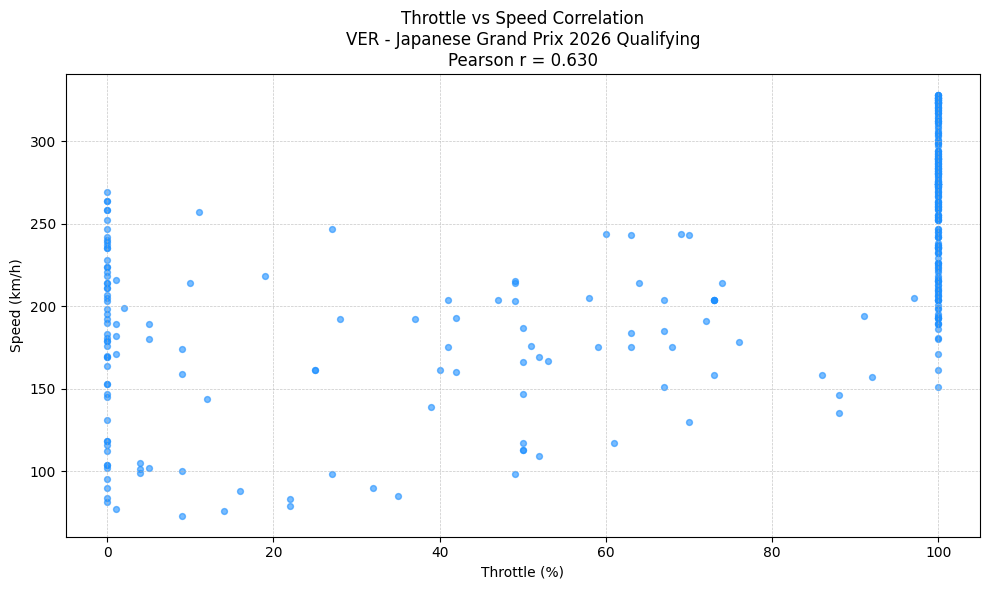

np.float64(0.6298315091818721)

In [9]:
corr_data = temp_data[['Throttle', 'Speed']].dropna()
throttle_speed_corr = corr_data.corr().loc['Throttle', 'Speed']

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    corr_data['Throttle'],
    corr_data['Speed'],
    color='dodgerblue',
    alpha=0.6,
    s=18
)

ax.set_title(
    f"Throttle vs Speed Correlation\n{dvr_1} - {session.event['EventName']} {session.event.year} Qualifying\nPearson r = {throttle_speed_corr:.3f}"
)
ax.set_xlabel('Throttle (%)')
ax.set_ylabel('Speed (km/h)')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

throttle_speed_corr


# 3

In [11]:
# Group by speed by throttle bins
temp_data['Throttle_bin'] = pd.cut(temp_data['Throttle'], bins=10)

# Show the data by throttle bins
throttle_bin_means = temp_data.groupby('Throttle_bin')['Speed'].mean()
throttle_bin_means

C:\Users\arkan\AppData\Local\Temp\ipykernel_18736\346283168.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_data['Throttle_bin'] = pd.cut(temp_data['Throttle'], bins=10)
C:\Users\arkan\AppData\Local\Temp\ipykernel_18736\346283168.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  throttle_bin_means = temp_data.groupby('Throttle_bin')['Speed'].mean()


Throttle_bin
(-0.1, 10.0]     176.732394
(10.0, 20.0]     156.600000
(20.0, 30.0]     145.857143
(30.0, 40.0]     133.400000
(40.0, 50.0]     167.266667
(50.0, 60.0]     177.857143
(60.0, 70.0]     188.750000
(70.0, 80.0]     194.625000
(80.0, 90.0]     146.333333
(90.0, 100.0]    265.247664
Name: Speed, dtype: float64

In [12]:
temp_data.head()

,Distance,Throttle,Speed,Throttle_bin
0,2.955556,100.0,280.0,"(90.0, 100.0]"
1,21.822222,100.0,283.0,"(90.0, 100.0]"
2,47.333333,100.0,287.0,"(90.0, 100.0]"
3,66.933333,100.0,294.0,"(90.0, 100.0]"
4,83.266667,100.0,294.0,"(90.0, 100.0]"


In [20]:
temp_data.info()

<class 'fastf1.core.Telemetry'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Distance      347 non-null    float64 
 1   Throttle      347 non-null    float64 
 2   Speed         347 non-null    float64 
 3   Throttle_bin  347 non-null    category
dtypes: category(1), float64(3)
memory usage: 9.0 KB


In [22]:
# Only show bins from a spesific partions
temp_data_1 = temp_data[temp_data['Throttle_bin'].astype(str) == '(90.0, 100.0]']
temp_data_1

,Distance,Throttle,Speed,Throttle_bin
0,2.955556,100.0,280.0,"(90.0, 100.0]"
1,21.822222,100.0,283.0,"(90.0, 100.0]"
2,47.333333,100.0,287.0,"(90.0, 100.0]"
3,66.933333,100.0,294.0,"(90.0, 100.0]"
4,83.266667,100.0,294.0,"(90.0, 100.0]"
...,...,...,...,...
342,5703.458333,100.0,259.0,"(90.0, 100.0]"
343,5714.941667,100.0,260.0,"(90.0, 100.0]"
344,5732.341667,100.0,261.0,"(90.0, 100.0]"
345,5747.008333,100.0,264.0,"(90.0, 100.0]"


# 4

In [ ]:
# Selecting drivers and preparing data for plotting
dvr_1 = 'VER'
dvr_2 = 'PIA'

dvr_1_lap = session.laps.pick_drivers(dvr_1).pick_fastest()
dvr_2_lap = session.laps.pick_drivers(dvr_2).pick_fastest()

dvr_1_tel = dvr_1_lap.get_car_data().add_distance()
dvr_2_tel = dvr_2_lap.get_car_data().add_distance()

dvr_1_team_col = fastf1.plotting.get_team_color(dvr_1_lap['Team'], session=session)
dvr_2_team_col = fastf1.plotting.get_team_color(dvr_2_lap['Team'], session=session)

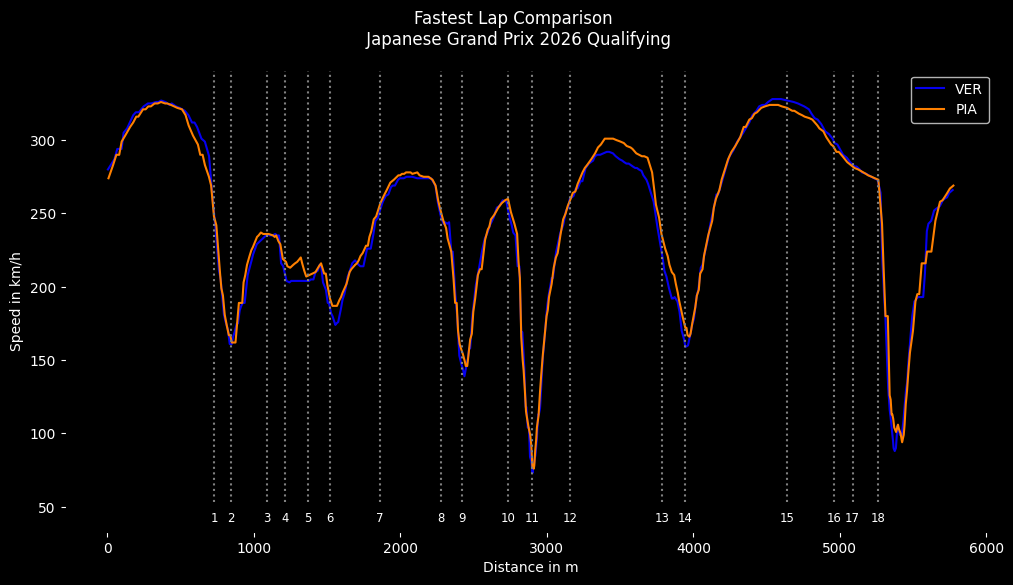

In [15]:
# Prepare plot data 
circuit_info = session.get_circuit_info()
dvr_1_speed = dvr_1_tel[['Distance', 'Speed']].sort_values('Distance').reset_index(drop=True)
dvr_2_speed = dvr_2_tel[['Distance', 'Speed']].sort_values('Distance').reset_index(drop=True)

# Figure settings
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor('black')
fig.patch.set_facecolor('black')
ax.tick_params(colors='white')
ax.title.set_color('white')

# Driver plot
ax.plot(dvr_1_tel['Distance'], 
        dvr_1_tel['Speed'], 
        color=dvr_1_team_col, 
        label=f'{dvr_1}')

ax.plot(dvr_2_tel['Distance'], 
        dvr_2_tel['Speed'], 
        color=dvr_2_team_col, 
        label=f'{dvr_2}')

# Set axis labels
ax.set_xlabel('Distance in m', color='white')
ax.set_ylabel('Speed in km/h', color='white')

# Set plot legend
ax.legend(loc='upper right', 
          facecolor='black', 
          framealpha=0.7, 
          edgecolor='white',
          labelcolor='white')

# Change font to white
plt.suptitle(f"Fastest Lap Comparison \n "
             f"{session.event['EventName']} {session.event.year} Qualifying", color='white')

# Add vertical lines at each corner position
v_min = min(dvr_1_tel['Speed'].min(), dvr_2_tel['Speed'].min())
v_max = max(dvr_1_tel['Speed'].max(), dvr_2_tel['Speed'].max())
ax.vlines(x=circuit_info.corners['Distance'], ymin=v_min-20, ymax=v_max+20,
          linestyles='dotted', colors='grey')

# Annotate corners
for _, corner in circuit_info.corners.iterrows():
    txt = f"{corner['Number']}{corner['Letter']}"
    ax.text(corner['Distance'], v_min-30, txt,
            va='center_baseline', ha='center', size='small', color='white')

# Adjust y-limits
ax.set_ylim([v_min - 40, v_max + 20])

plt.show()

In [ ]:
x